In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
exp = pd.read_csv("results/experiments_resnet.csv")
cur = pd.read_csv("results/curves_resnet.csv")
exp

,timestamp,model,pretrained_weights,optimizer,learning_rate,batch_size,num_epochs,weight_decay,dropout,scheduler,data_augmentation,best_val_acc,training_time_s
0,1773854727,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0001,0.0,NaN,simple,0.831408,5046.79
1,1773860089,resnet18,IMAGENET1K_V1,SGD,0.010,64,40,0.0001,0.0,NaN,simple,0.833822,5147.42
2,1773951309,resnet18,IMAGENET1K_V1,SGD,0.100,32,40,0.0001,0.0,NaN,simple,0.749590,4597.51
3,1773956425,resnet18,IMAGENET1K_V1,SGD,0.001,32,40,0.0001,0.0,NaN,simple,0.837233,4560.68
4,1774127730,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0001,0.5,NaN,simple,0.829107,5190.80
5,1774215986,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0100,0.0,NaN,simple,0.540462,5469.76
6,1774114136,resnet18,IMAGENET1K_V1,SGD,0.010,128,40,0.0001,0.0,NaN,simple,0.833286,4597.16
7,1774123761,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0001,0.3,NaN,simple,0.827784,4545.52
8,1774208490,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0010,0.0,NaN,simple,0.769836,5248.91
9,1774296348,resnet18,IMAGENET1K_V1,SGD,0.010,32,15,0.0001,0.0,NaN,advanced,0.799230,2315.73


In [12]:
cur

,timestamp,epoch,train_loss,train_acc,val_loss,val_acc
0,1773854727,1,1.318890,0.534168,0.921538,0.680964
1,1773854727,2,0.880015,0.689805,0.771860,0.728031
2,1773854727,3,0.742243,0.737154,0.674414,0.760333
3,1773854727,4,0.665419,0.763176,0.649252,0.771554
4,1773854727,5,0.603162,0.786587,0.625471,0.779838
...,...,...,...,...,...,...
385,1773612545,11,0.127624,0.955692,0.962249,0.765358
386,1773612545,12,0.114178,0.960027,1.033406,0.763542
387,1773612545,13,0.097906,0.966129,1.052337,0.755771
388,1773612545,14,0.087669,0.969727,1.139523,0.751037


In [14]:
cur = cur[cur['epoch'] <= 15]
# min loss on valid for each model
min_loss = cur.groupby('timestamp')[['epoch','val_loss']].agg('min')
# max acc on valid for each model
max_acc = cur.groupby('timestamp')['val_acc'].agg('max')

In [4]:
hyperparams= {
    "learning_rate": [0.1, 0.001],
    "batch_size": [64, 128],
    "weight_decay": [0.001, 0.01],
    "dropout": [0.3, 0.5],
    "data_augmentation": ["raw", "advanced"]
}
ts = []
for key, value in hyperparams.items():
    for v in value:
        ts.append(int(exp[exp[key] == v]["timestamp"].iloc[0]))

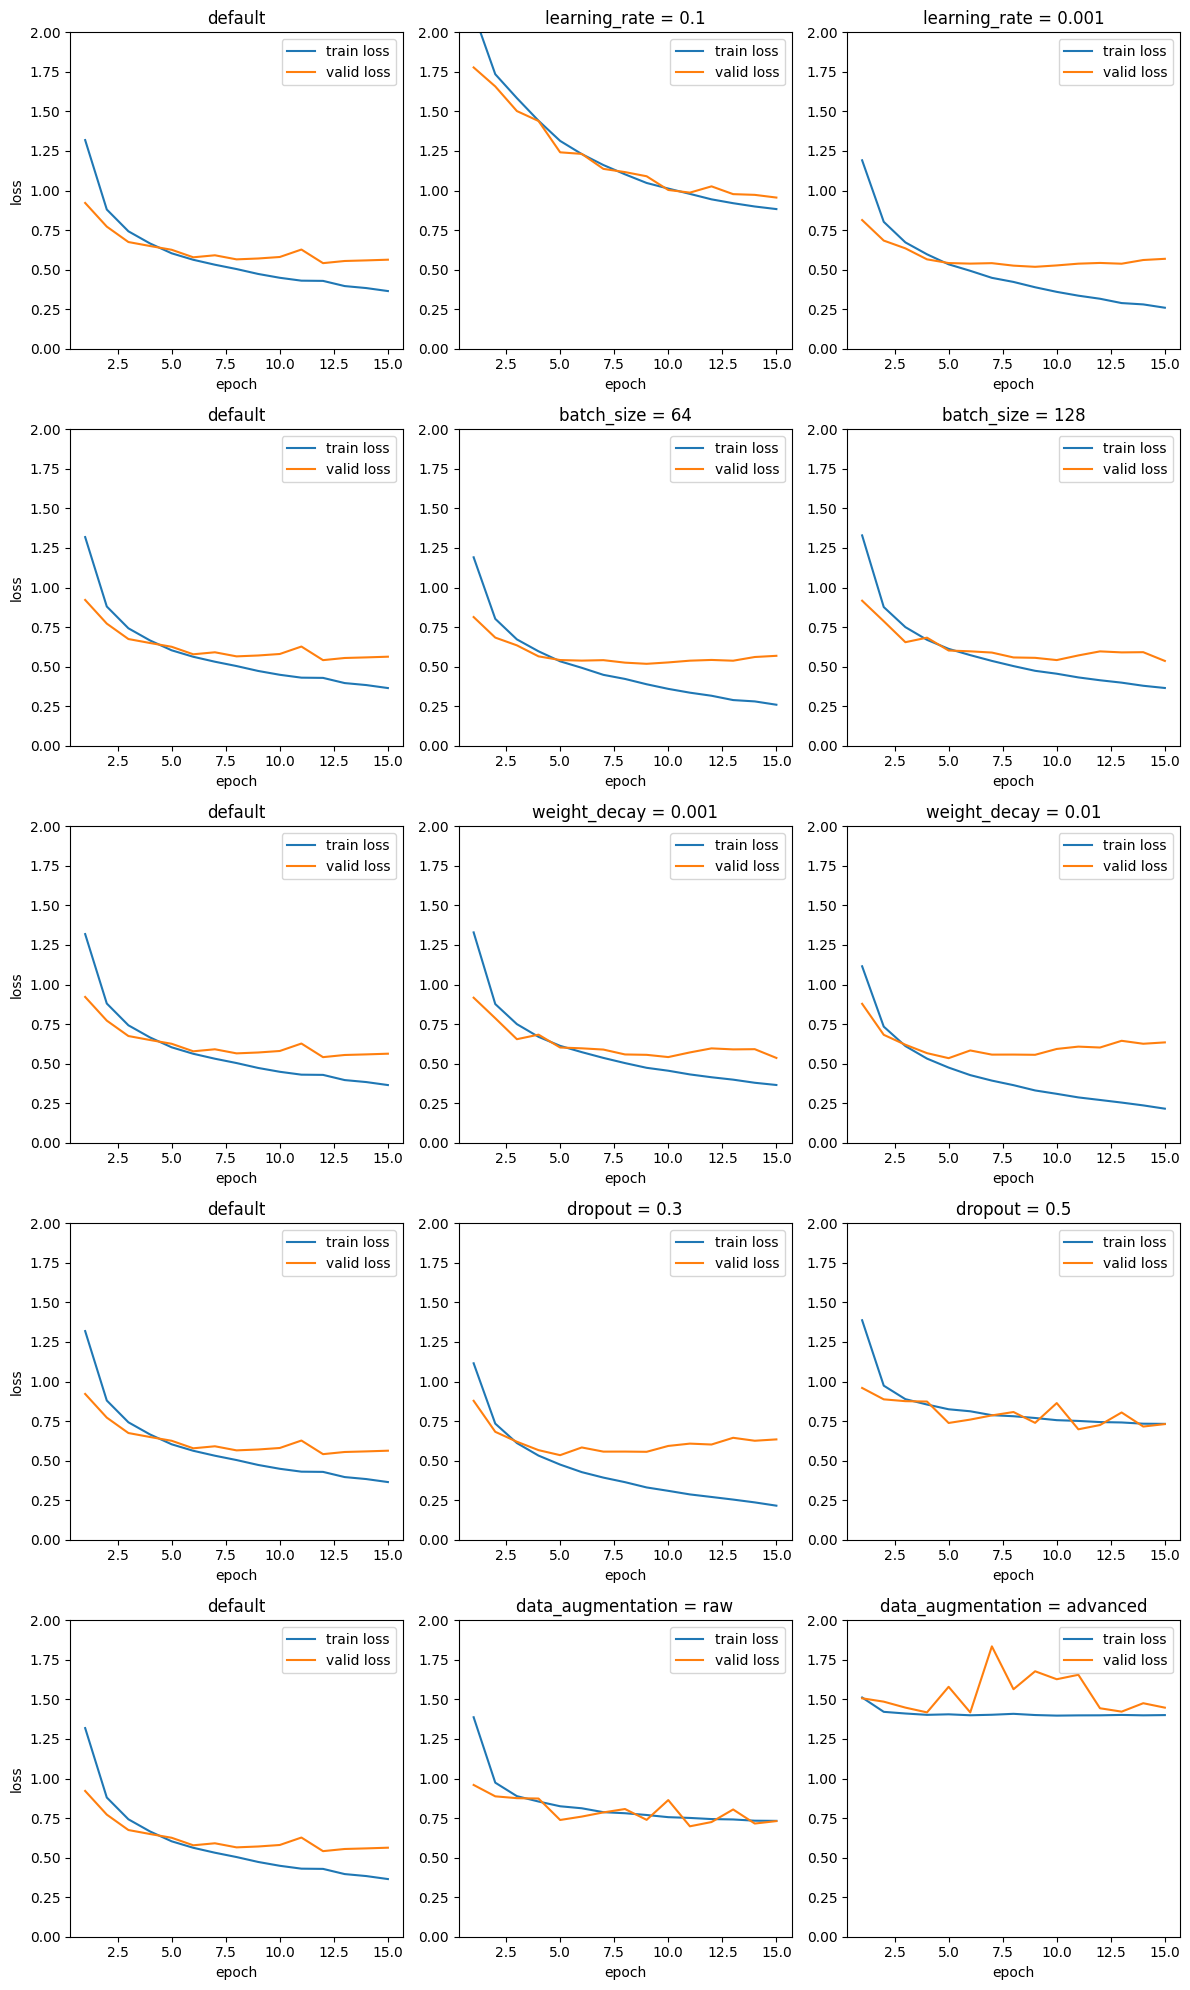

In [ ]:
ts_default = 1773854727
epoch = [i+1 for i in range(15)]

fig, axs = plt.subplots(5, 3, figsize=(12, 20))
i = 0
for key, value in hyperparams.items():
    axs[i, 0].plot(
        epoch, cur[cur["timestamp"] == ts_default]["train_loss"], label="train loss"
    )
    axs[i, 0].plot(
        epoch, cur[cur["timestamp"] == ts_default]["val_loss"], label="valid loss"
    )
    # axs[i, 0].plot(
    #     epoch, cur[cur["timestamp"] == ts_default]["train_acc"], label="train acc"
    # )
    # axs[i, 0].plot(
    #     epoch, cur[cur["timestamp"] == ts_default]["val_acc"], label="valid acc"
    # )
    axs[i, 0].legend()
    axs[i, 0].set_ylim(0, 2)
    axs[i, 0].set_title("default")
    axs[i, 0].set_xlabel("epoch")
    axs[i, 0].set_ylabel("loss")

    axs[i, 1].plot(
        epoch, cur[cur["timestamp"] == ts[i]]["train_loss"], label="train loss"
    )
    axs[i, 1].plot(
        epoch, cur[cur["timestamp"] == ts[i]]["val_loss"], label="valid loss"
    )
    axs[i, 1].scatter(min_epoch["timestamp"], min_loss["timestamp"], color="red", label="min val loss")
    # axs[i, 1].plot(
    #     epoch, cur[cur["timestamp"] == ts[i]]["train_acc"], label="train acc"
    # )
    # axs[i, 1].plot(
    #     epoch, cur[cur["timestamp"] == ts[i]]["val_acc"], label="valid acc"
    # )
    axs[i, 1].legend()
    axs[i, 1].set_title(f"{key} = {value[0]}")
    axs[i, 1].set_ylim(0, 2)
    axs[i, 1].set_xlabel("epoch")

    axs[i, 2].plot(
        epoch, cur[cur["timestamp"] == ts[i + 1]]["train_loss"], label="train loss"
    )
    axs[i, 2].plot(
        epoch, cur[cur["timestamp"] == ts[i + 1]]["val_loss"], label="valid loss"
    )
    # axs[i, 2].plot(
    #     epoch, cur[cur["timestamp"] == ts[i+1]]["train_acc"], label="train acc"
    # )
    # axs[i, 2].plot(
    #     epoch, cur[cur["timestamp"] == ts[i+1]]["val_acc"], label="valid acc"
    # )
    axs[i, 2].legend()
    axs[i, 2].set_title(f"{key} = {value[1]}")
    axs[i, 2].set_ylim(0, 2)
    axs[i, 2].set_xlabel("epoch")
    i += 1
plt.tight_layout()
# axs.show_legend()
plt.show()

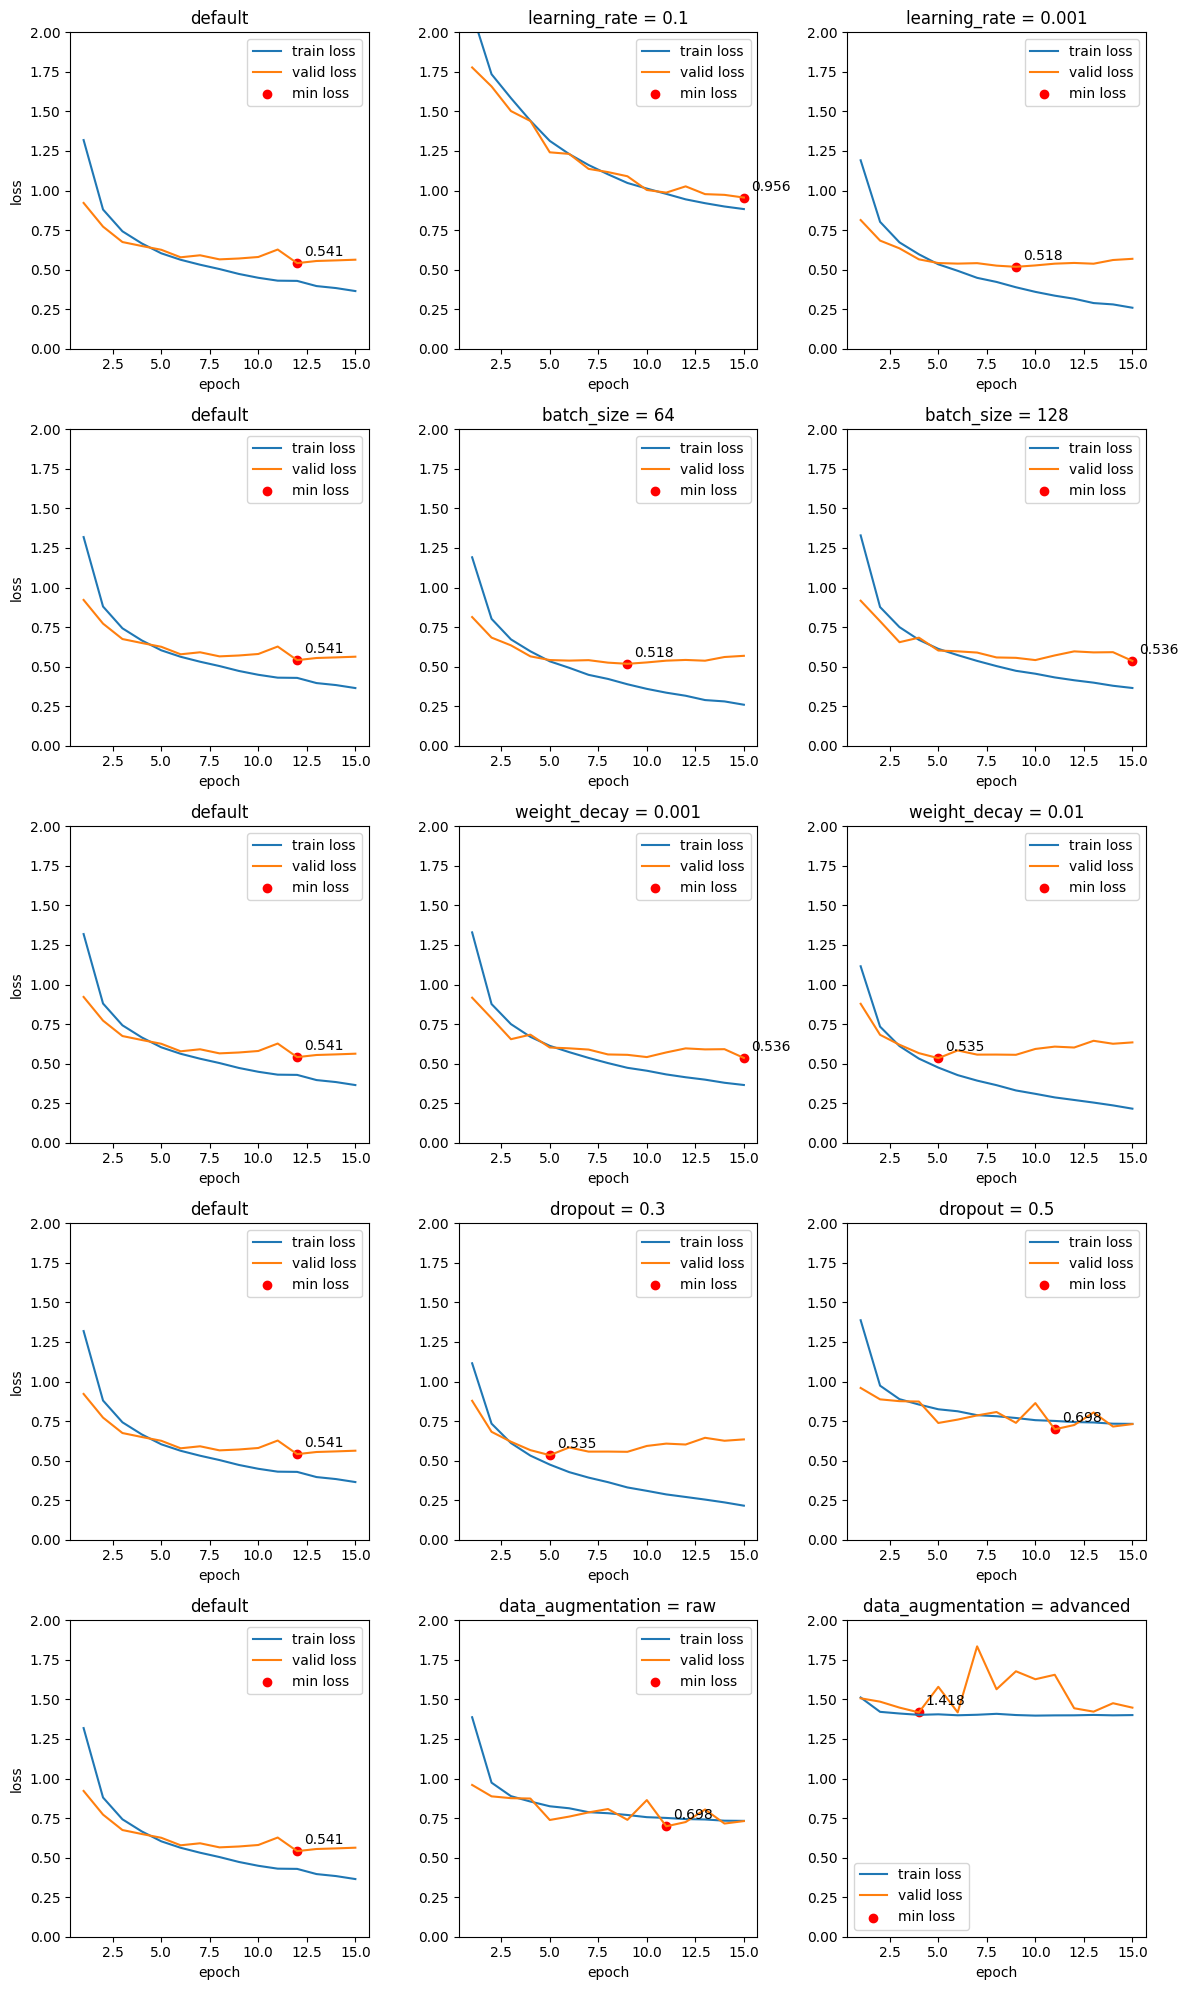

In [ ]:
ts_default = 1773854727

fig, axs = plt.subplots(5, 3, figsize=(12, 20))

i = 0
for key, value in hyperparams.items():
    cur_def = cur[cur["timestamp"] == ts_default]
    axs[i, 0].plot(cur_def["epoch"], cur_def["train_loss"], label="train loss")
    axs[i, 0].plot(cur_def["epoch"], cur_def["val_loss"], label="valid loss")
    min_def = cur_def.loc[cur_def["val_loss"].idxmin()]
    axs[i, 0].scatter(min_def["epoch"], min_def["val_loss"], color="red", label="min loss")
    axs[i, 0].annotate(f'{min_def["val_loss"]:.3f}',
                       (min_def["epoch"], min_def["val_loss"]),
                       textcoords="offset points", xytext=(5, 5))
    axs[i, 0].legend()
    axs[i, 0].set_ylim(0, 2)
    axs[i, 0].set_title("default")
    axs[i, 0].set_xlabel("epoch")
    axs[i, 0].set_ylabel("loss")


    cur_ts = cur[cur["timestamp"] == ts[i]]
    axs[i, 1].plot(cur_ts["epoch"], cur_ts["train_loss"], label="train loss")
    axs[i, 1].plot(cur_ts["epoch"], cur_ts["val_loss"], label="valid loss")
    min_row = cur_ts.loc[cur_ts["val_loss"].idxmin()]
    axs[i, 1].scatter(min_row["epoch"], min_row["val_loss"], color="red", label="min loss")
    axs[i, 1].annotate(f'{min_row["val_loss"]:.3f}',
                       (min_row["epoch"], min_row["val_loss"]),
                       textcoords="offset points", xytext=(5, 5))
    axs[i, 1].legend()
    axs[i, 1].set_title(f"{key} = {value[0]}")
    axs[i, 1].set_ylim(0, 2)
    axs[i, 1].set_xlabel("epoch")


    cur_ts2 = cur[cur["timestamp"] == ts[i + 1]]
    axs[i, 2].plot(cur_ts2["epoch"], cur_ts2["train_loss"], label="train loss")
    axs[i, 2].plot(cur_ts2["epoch"], cur_ts2["val_loss"], label="valid loss")
    min_row2 = cur_ts2.loc[cur_ts2["val_loss"].idxmin()]
    axs[i, 2].scatter(min_row2["epoch"], min_row2["val_loss"], color="red", label="min loss")
    axs[i, 2].annotate(f'{min_row2["val_loss"]:.3f}',
                       (min_row2["epoch"], min_row2["val_loss"]),
                       textcoords="offset points", xytext=(5, 5))
    axs[i, 2].legend()
    axs[i, 2].set_title(f"{key} = {value[1]}")
    axs[i, 2].set_ylim(0, 2)
    axs[i, 2].set_xlabel("epoch")

    i += 1

plt.tight_layout()
plt.show()